In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/resourcemanager.zip"

extract_path = "/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed")
print("\nExtracted files/folders:")

for item in os.listdir(extract_path):
    print(item)

In [3]:
import numpy as np
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from pathlib import Path
from google.colab import userdata

**1. Provide the path of java files and load their source code into a list**

In [4]:
from pathlib import Path

SOURCE_CODE_DIR = Path("/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/resourcemanager/scheduler/capacity")
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/output"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
files_list = []
# Reloading files from the MapReduce directory
for file_path in SOURCE_CODE_DIR.rglob('*.java'):
    if file_path.is_file():
        with open(file_path, 'r', encoding='utf-8') as f:
            files_list.append(f.read())

**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [6]:
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [7]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # What is loaded in 4 bit? why?
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

In [8]:
# 1. Install dependencies.
# IMPORTANT: Restart session (Runtime > Restart session) after this finishes.
!pip install -U bitsandbytes>=0.46.1 accelerate

**4. Generate embeddings**

In [9]:
embedding_model_name = "jinaai/jina-code-embeddings-0.5b"

In [10]:
tokenizer = AutoTokenizer.from_pretrained(embedding_model_name, token=hf_token)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    # Attempting 4-bit loading
    model = AutoModel.from_pretrained(
        embedding_model_name,
        token=hf_token,
        quantization_config=bnb_config,
        device_map="auto"
    )
    print("Model loaded successfully with 4-bit quantization.")
except Exception as e:
    print(f"Quantization failed or bitsandbytes not found: {e}")
    print("Falling back to standard loading...")
    model = AutoModel.from_pretrained(embedding_model_name, token=hf_token)
    model.to(device)

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model loaded successfully with 4-bit quantization.


**5. Construct the semantic similarity matrix**

In [11]:
def embed_source_code(code_files):
    embeddings = []
    # Ensure model is in eval mode and correct dtype
    model.eval()

    for code in code_files:
        # Max length 512
        inputs = tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            # We force the model to compute in float32 if on CPU or if BFloat16 is unsupported
            outputs = model(**inputs)
            # Take the mean of the token embeddings
            # Ensure we are working with float32 for the mean calculation to avoid the BFloat16 error
            code_embedding = outputs.last_hidden_state.to(torch.float32).mean(dim=1).squeeze().cpu().numpy()
        embeddings.append(code_embedding)
    return np.array(embeddings)

In [12]:
print(f"Number of files found: {len(files_list)}")

Number of files found: 99


In [13]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Initialize with zeros to prevent NameErrors in later cells
global semantic_matrix
semantic_matrix = np.zeros((len(files_list), len(files_list)))

# Check if function exists in globals
if 'embed_source_code' in globals() and len(files_list) > 0:
    print(f"Generating embeddings for {len(files_list)} files...")
    try:
        embeddings_array = embed_source_code(files_list)
        if embeddings_array is not None and len(embeddings_array) > 0:
            semantic_matrix = cosine_similarity(embeddings_array)
            print(f"Semantic similarity matrix constructed: {semantic_matrix.shape}")
    except Exception as e:
        print(f"Error during embedding generation: {e}")
else:
    print("CRITICAL: 'embed_source_code' function not found. Please ensure you have executed cell k3zp8OnDD4re before running this cell.")

Generating embeddings for 99 files...
Semantic similarity matrix constructed: (99, 99)


**6. Construct the structural similarity matrix**

In [14]:
import re
import numpy as np
from pathlib import Path

def get_full_class_name(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        package_match = re.search(r'^\s*package\s+([^;]+);', content, re.MULTILINE)
        package = package_match.group(1).strip() if package_match else ""
        class_name = Path(file_path).stem
        return f"{package}.{class_name}" if package else class_name

full_class_names = [get_full_class_name(p) for p in SOURCE_CODE_DIR.rglob('*.java') if p.is_file()]
num_files = len(full_class_names)
struct_matrix_raw = np.zeros((num_files, num_files))

dependencies = {}
rsf_path = "/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/filtered_rsf.rsf"

if not Path(rsf_path).exists():
    print(f"CRITICAL ERROR: {rsf_path} not found. Please upload the RSF file to the /content/ folder.")
else:
    try:
        with open(rsf_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3 and parts[0] == 'depends':
                    source, target = parts[1], parts[2]
                    if source not in dependencies: dependencies[source] = set()
                    dependencies[source].add(target)

        for i in range(num_files):
            for j in range(i, num_files):
                set_i = dependencies.get(full_class_names[i], set())
                set_j = dependencies.get(full_class_names[j], set())
                common_count = len(set_i.intersection(set_j))
                struct_matrix_raw[i, j] = struct_matrix_raw[j, i] = common_count

        print(f"Structural matrix constructed. Shape: {struct_matrix_raw.shape}")
        print(f"Max overlap found: {struct_matrix_raw.max()}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Structural matrix constructed. Shape: (99, 99)
Max overlap found: 162.0


**7. Normalize the structural matrix**

In [15]:
# Normalizing the structural matrix to a 0-1 range
max_overlap = struct_matrix_raw.max()
if max_overlap > 0:
    struct_matrix = struct_matrix_raw / max_overlap
else:
    struct_matrix = struct_matrix_raw

# Diagonals represent a file's similarity to itself, which is always 1.0
np.fill_diagonal(struct_matrix, 1.0)

print(f"Structural matrix normalized. Max value: {struct_matrix.max()}")

Structural matrix normalized. Max value: 1.0


**8. Combine the two matrices into one similarity matrix then apply complement.**

In [16]:
# ALPHA dictates the weight of structural vs. semantic data.
# 0.5 gives equal weight to both dependency structure and code meaning.
ALPHA = 0.5
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Invert similarity to get distance (Clustering algorithms use distance)
distance_matrix = 1.0 - combined_similarity

# Ensure diagonal is exactly 0 (distance to self)
np.fill_diagonal(distance_matrix, 0)

print("Combined distance matrix calculated successfully.")

Combined distance matrix calculated successfully.


**9. Apply clustering**

In [17]:
print(distance_matrix)

[[0.         0.57607108 0.56566297 ... 0.60799515 0.66962025 0.66700625]
 [0.57607108 0.         0.53949425 ... 0.5563046  0.67050418 0.670172  ]
 [0.56566297 0.53949425 0.         ... 0.58439049 0.64669865 0.65507638]
 ...
 [0.60799515 0.5563046  0.58439049 ... 0.         0.66552174 0.66263303]
 [0.66962025 0.67050418 0.64669865 ... 0.66552174 0.         0.67499548]
 [0.66700625 0.670172   0.65507638 ... 0.66263303 0.67499548 0.        ]]


In [18]:
# Final clustering for Week 3
TARGET_NUM_CLUSTERS = 10
clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage='complete')
clusters = clusterer.fit_predict(distance_matrix)

print(f"Clustering complete! {len(clusters)} YARN ResourceManager files grouped into {TARGET_NUM_CLUSTERS} clusters.")

Clustering complete! 99 YARN ResourceManager files grouped into 10 clusters.


**10. Visulizations**

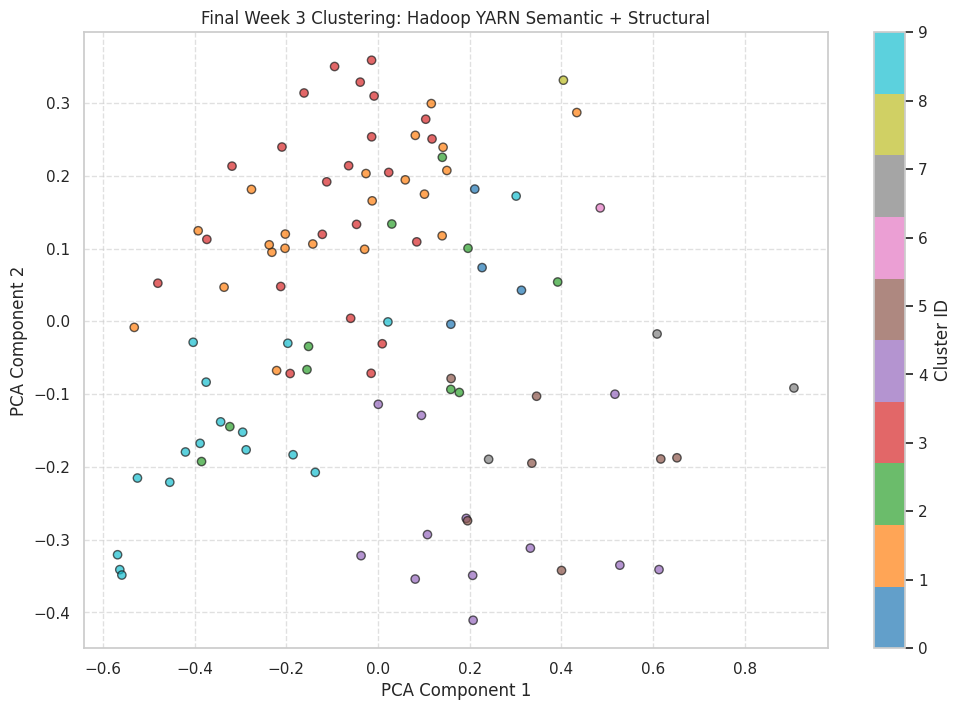

In [29]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Visualization using PCA to project the combined distance matrix into 2D
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(distance_matrix)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='tab10', alpha=0.7, edgecolors='k')
plt.title('Final Week 3 Clustering: Hadoop YARN Semantic + Structural')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

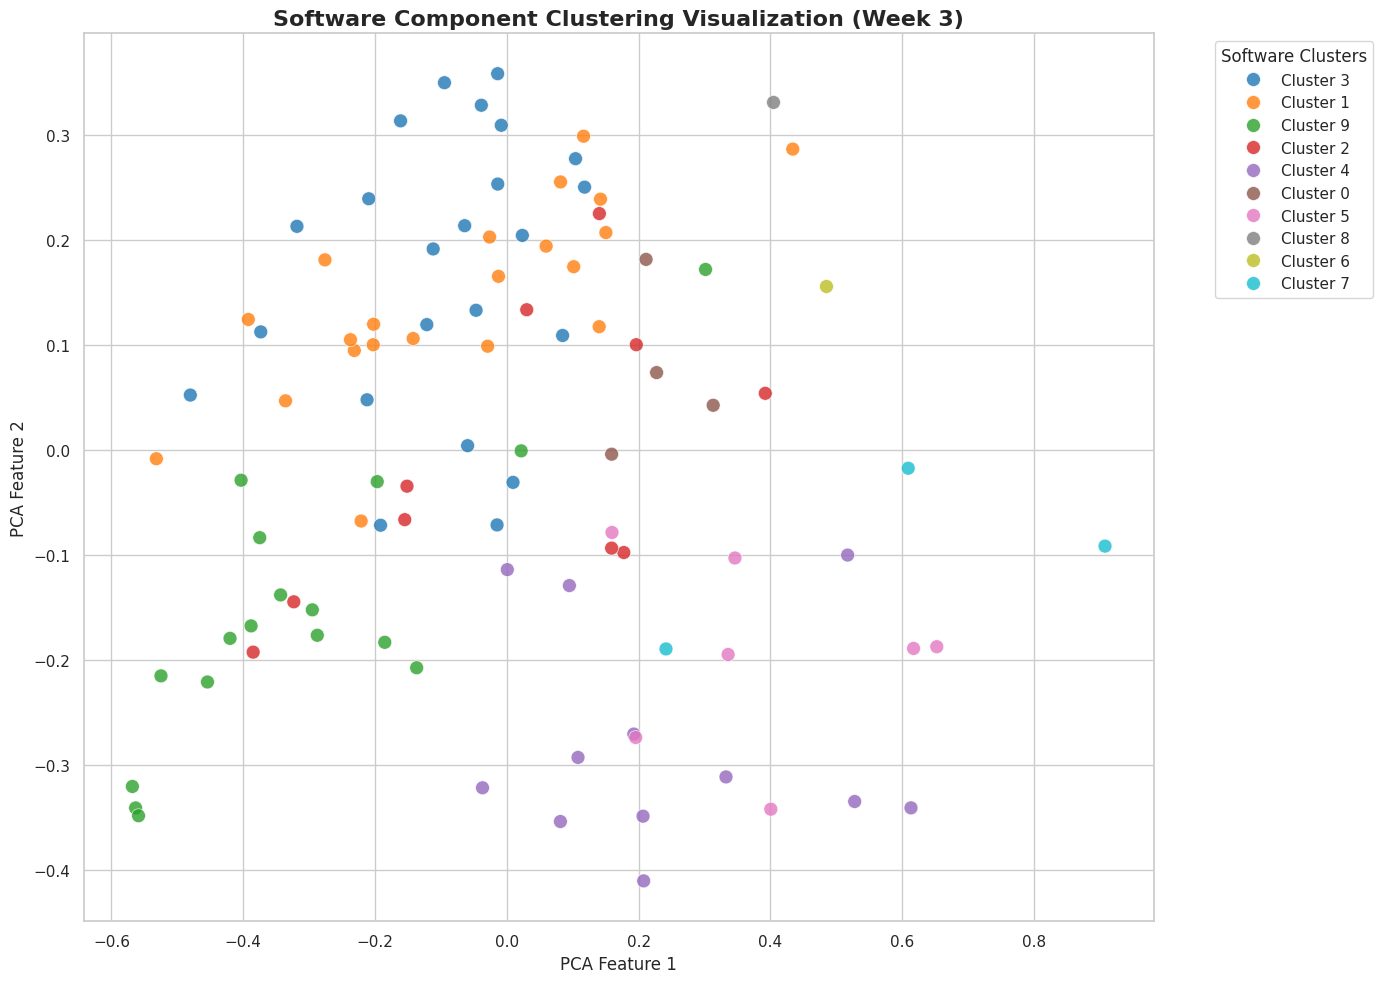

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a more readable dataframe for plotting
plot_df = pd.DataFrame({
    'x': reduced_data[:, 0],
    'y': reduced_data[:, 1],
    'Cluster': [f'Cluster {c}' for c in clusters]
})

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 10))

# Create the scatter plot with a legend
scatter_plot = sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='Cluster',
    palette='tab10',
    s=100,
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Software Component Clustering Visualization (Week 3)', fontsize=16, fontweight='bold')
plt.xlabel('PCA Feature 1', fontsize=12)
plt.ylabel('PCA Feature 2', fontsize=12)

# Move legend to the side for better visibility
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Software Clusters')

plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

# Aligning lengths to avoid ValueError
min_length = min(len(full_class_names), len(clusters))

# Create a mapping of File Name to Cluster ID
results_df = pd.DataFrame({
    'Full_Class_Name': full_class_names[:min_length],
    'Cluster_ID': clusters[:min_length]
})

# Save to the output directory
output_file = OUTPUT_DIR / "clustering_results.csv"
results_df.to_csv(output_file, index=False)

print(f"Results saved to: {output_file}")
print(f"Aligned to {min_length} files.")
display(results_df.head())

Results saved to: /content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/output/clustering_results.csv
Aligned to 99 files.


,Full_Class_Name,Cluster_ID
0,org.apache.hadoop.yarn.server.resourcemanager....,3
1,org.apache.hadoop.yarn.server.resourcemanager....,1
2,org.apache.hadoop.yarn.server.resourcemanager....,9
3,org.apache.hadoop.yarn.server.resourcemanager....,9
4,org.apache.hadoop.yarn.server.resourcemanager....,1


In [22]:
# Define the output path for the RSF file
rsf_output_path = OUTPUT_DIR / "final_clustering_jina_code_embeddings.rsf"

# Open file and write clustering results in RSF format
# Format: contain <Cluster_ID> <Full_Class_Name>
with open(rsf_output_path, 'w') as f:
    for _, row in results_df.iterrows():
        f.write(f"contain Cluster_{row['Cluster_ID']} {row['Full_Class_Name']}\n")

print(f"RSF file generated successfully at: {rsf_output_path}")

# Display the first few lines of the generated RSF
!head -n 5 {rsf_output_path}

RSF file generated successfully at: /content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/output/final_clustering_jina_code_embeddings.rsf
contain Cluster_3 org.apache.hadoop.yarn.server.resourcemanager.scheduler.capacity.AbsoluteResourceCapacityCalculator
contain Cluster_1 org.apache.hadoop.yarn.server.resourcemanager.scheduler.capacity.AbstractAutoCreatedLeafQueue
contain Cluster_9 org.apache.hadoop.yarn.server.resourcemanager.scheduler.capacity.AbstractCSQueue
contain Cluster_9 org.apache.hadoop.yarn.server.resourcemanager.scheduler.capacity.AbstractLeafQueue
contain Cluster_1 org.apache.hadoop.yarn.server.resourcemanager.scheduler.capacity.AbstractManagedParentQueue


### Experiment: Adjust Hyperparameters
Use this cell to tweak the balance between structure and semantics, or change the granularity of the clusters.

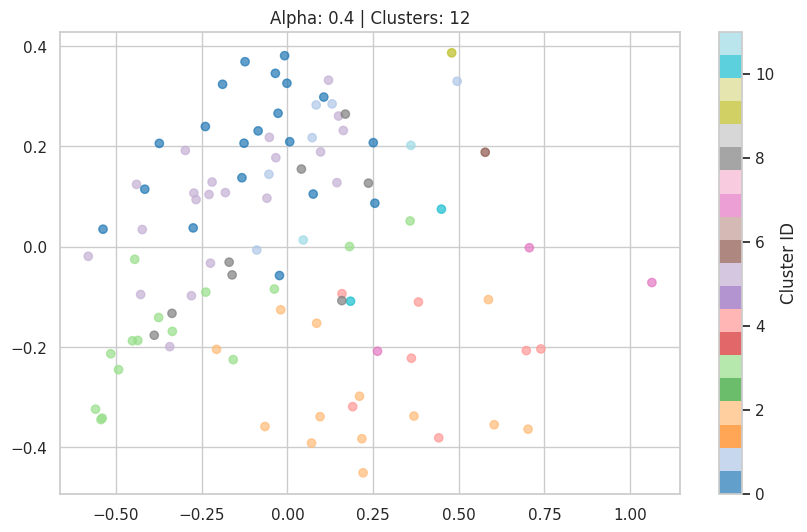

In [23]:
# @title Clustering Experimentation { run: "auto" }
NEW_ALPHA = 0.4 # @param {type:"slider", min:0, max:1, step:0.1}
NEW_TARGET_CLUSTERS = 12 # @param {type:"slider", min:2, max:30, step:1}

# 1. Re-calculate distance matrix
combined_sim = (NEW_ALPHA * struct_matrix) + ((1 - NEW_ALPHA) * semantic_matrix)
dist_mat = 1.0 - combined_sim
np.fill_diagonal(dist_mat, 0)

# 2. Re-cluster
new_clusterer = AgglomerativeClustering(n_clusters=NEW_TARGET_CLUSTERS, metric='precomputed', linkage='complete')
new_clusters = new_clusterer.fit_predict(dist_mat)

# 3. Visualize the change
pca = PCA(n_components=2)
coords = pca.fit_transform(dist_mat)

plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=new_clusters, cmap='tab20', alpha=0.7)
plt.title(f'Alpha: {NEW_ALPHA} | Clusters: {NEW_TARGET_CLUSTERS}')
plt.colorbar(label='Cluster ID')
plt.show()

##Denodrogram


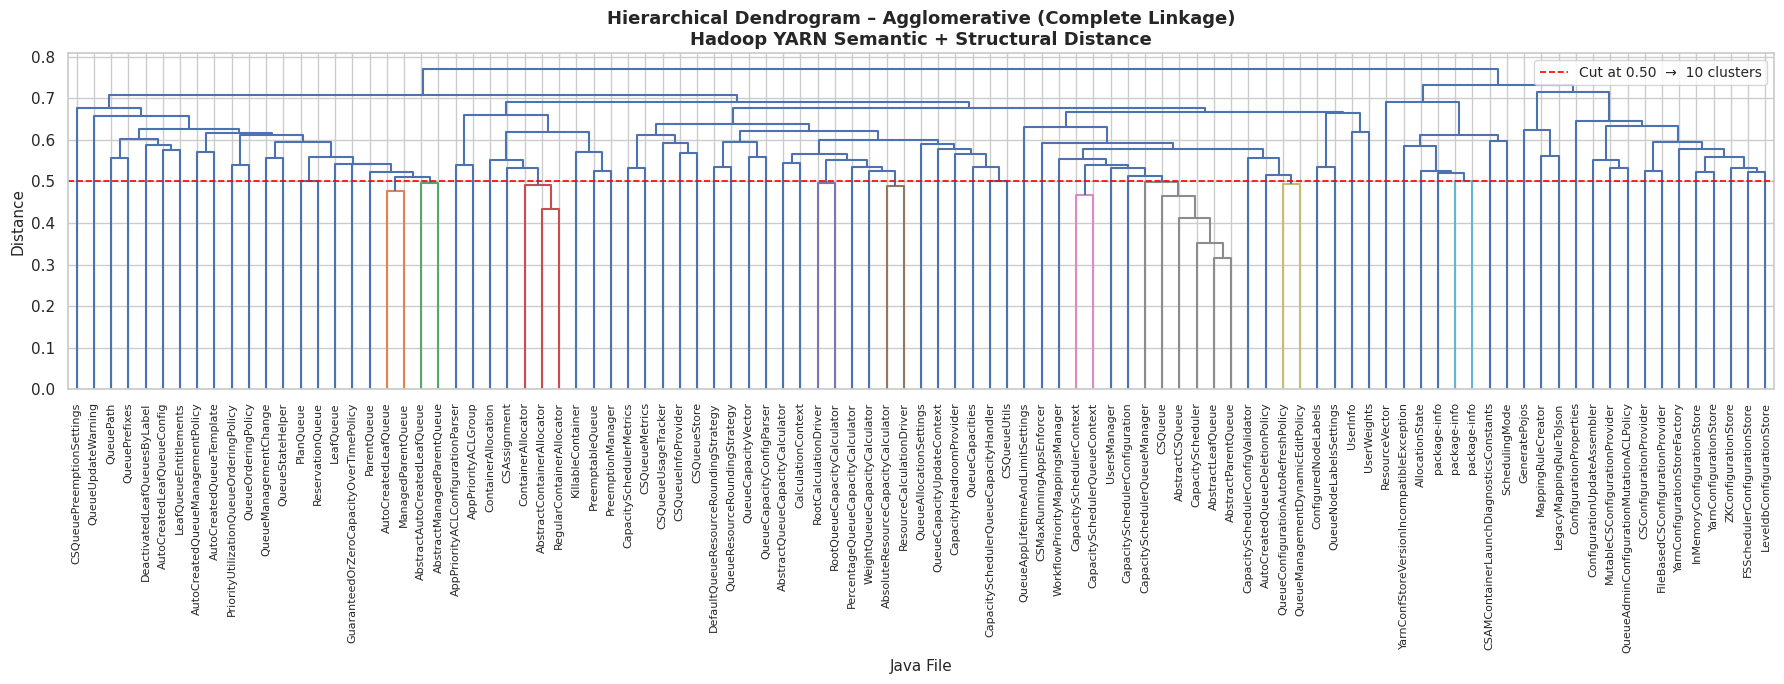

Saved: viz_dendrogram.png


In [33]:
# ── VISUALIZATION 1: Dendrogram (Complete-linkage) ─────────────────
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

# Use complete linkage (same method as AgglomerativeClustering above)
_dist = distance_matrix.copy()
np.fill_diagonal(_dist, 0)
_condensed = squareform(_dist)
Z = linkage(_condensed, method='complete')

# Shorten labels to just the filename stem
_labels = [str(p).split('/')[-1].replace('.java', '') for p in SOURCE_CODE_DIR.rglob('*.java') if p.is_file()]

fig, ax = plt.subplots(figsize=(18, 7))
dendrogram(
    Z,
    labels=_labels,
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.65 * max(Z[:, 2]),
)
cut_height = 0.65 * max(Z[:, 2])
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=1.2,
           label=f'Cut at {cut_height:.2f}  →  {TARGET_NUM_CLUSTERS} clusters')
ax.set_title('Hierarchical Dendrogram – Agglomerative (Complete Linkage)\nHadoop YARN Semantic + Structural Distance', fontsize=13, fontweight='bold')
ax.set_xlabel('Java File', fontsize=11)
ax.set_ylabel('Distance', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: viz_dendrogram.png")


##Cluster Distribution Chart

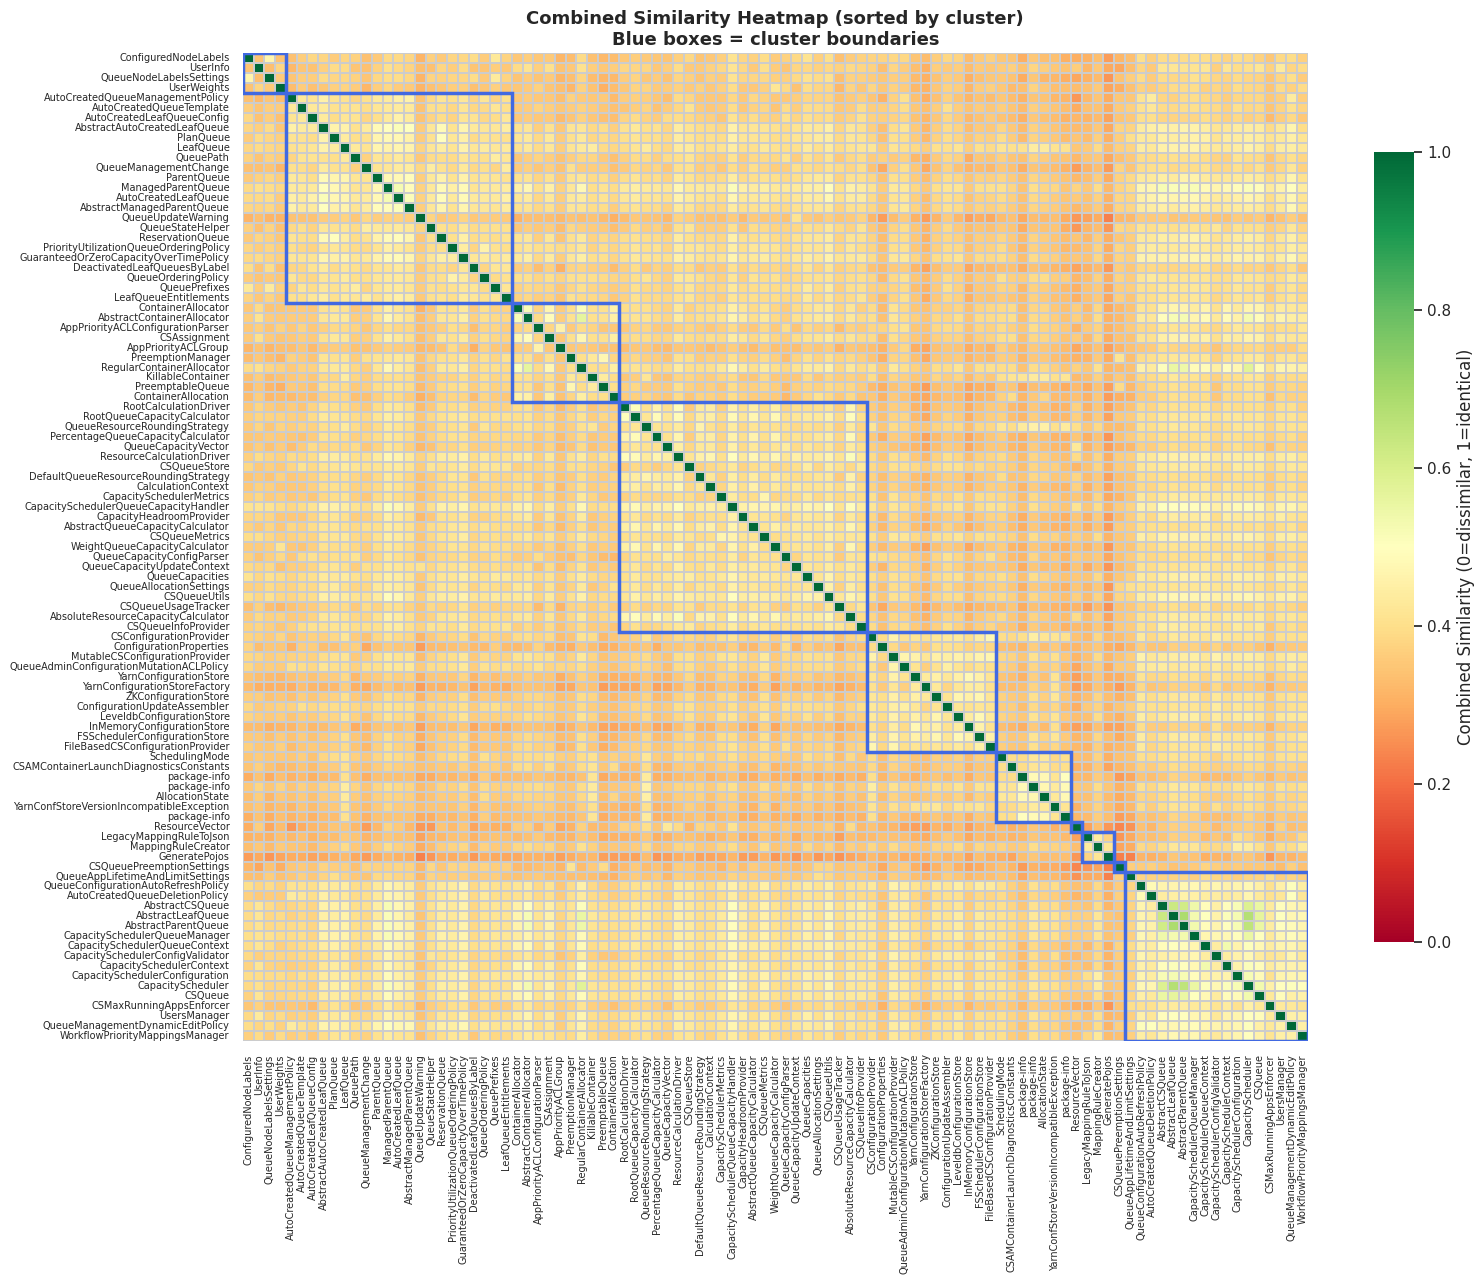

Saved: viz_heatmap.png


In [34]:
# ── VISUALIZATION 2: Annotated Similarity Heatmap ──────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Sort rows/cols by cluster so same-cluster files sit together
_sort_idx = np.argsort(clusters)
_sim_sorted = combined_similarity[np.ix_(_sort_idx, _sort_idx)]
_cluster_sorted = clusters[_sort_idx]
_labels_sorted = [_labels[i] for i in _sort_idx]

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    _sim_sorted,
    ax=ax,
    xticklabels=_labels_sorted,
    yticklabels=_labels_sorted,
    cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.3,
    linecolor='#cccccc',
    cbar_kws={'label': 'Combined Similarity (0=dissimilar, 1=identical)', 'shrink': 0.8},
)

# Draw blue boxes around each cluster block
_boundaries = np.where(np.diff(_cluster_sorted))[0] + 1
_positions = [0] + list(_boundaries) + [len(_labels_sorted)]
for _start, _end in zip(_positions[:-1], _positions[1:]):
    ax.add_patch(plt.Rectangle(
        (_start, _start), _end - _start, _end - _start,
        fill=False, edgecolor='royalblue', linewidth=2.5
    ))

ax.set_title('Combined Similarity Heatmap (sorted by cluster)\nBlue boxes = cluster boundaries', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: viz_heatmap.png")


##Similarity Heatmap

### Download Experiment Results
Run the cell below to package all generated files into a ZIP archive and download it to your local machine.

In [ ]:
from google.colab import files
import shutil

# Define the name for the zip file
zip_filename = "clustering_experiment_results"

# Create a zip archive of the results folder
shutil.make_archive(zip_filename, 'zip', BASE_OUTPUT)

# Trigger the download
files.download(f"{zip_filename}.zip")
print(f"Created and downloading {zip_filename}.zip")